# **Take Home Assignment**

## Scientific Computing - Session 1

- **Topic** : Personalized Mini-Scientific Toolkit & Decision Report
- **Deadline** : 5 Feb 2026 - 13 Feb 2026
- **Required Files** :
  1. Jupyter Notebook Source Code
  2. Exported Jupyter Notebook PDF

## Student Biodata

- **Name** : Ruben Wealth Hu
- **Student ID** : 2902583383
- **Class ID** : BE20 - LAB

---

_This Jupyter Notebook is served in Indonesian and English._

_Isi Notebook Jupyter ini disajikan dalam Bahasa Indonesia dan Inggris_


# **Latar Belakang (Background)**

Mahasiswa diminta untuk membangun sebuah _Scientific Computing Pipeline_ menggunakan bahasa pemograman Python yang digunakan untuk **menganalisis data numerik secara deterministik**, **mendeteksi outlier**, dan **menghasilkan keputusan berdasar aturan**. Seluruh proses harus dapat direproduksi dan setiap nilai numerik yang digunakan **wajib memiliki asal usul yang jelas**, baik dari digit NIM maupun dari statistik data yang dihitung.

Tugas dikerjakan secara individu dan dikumpulkan dalam bentuk Jupyter Notebook dan PDF hasil export, yang berisi persamaan matematis, penurunan parameter, dan interpretasi hasil.

---

_Students are asked to build a Scientific Computing Pipeline using the Python programming language to **deterministically analyze numerical data**, **detect outliers**, and **generate rule-based decisions**. The entire process must be reproducible, and each numerical value **must have a clear origin**, both from the student ID number and from the calculated data statistics._

_Assignments are completed individually and submitted in the form of a Jupyter Notebook and an exported PDF, containing mathematical equations, parameter derivations, and interpretation of the results._


# **Seksi Pengerjaan (Assignment Section)**


## Mengenerasi Data (_Generating Data_)

Dataset numerik $x$ memiliki panjang tetap $N=30$. Data dibentuk menggunakan persamaan berikut

(_The numeric dataset $x$ has a fixed length $N=30$. The data is formed using the following equation_)

$$x_{i} = (A \cdot i + B)modM + ϵ_{i}$$

Keterangan (_Description_):

- $A = d_1$ : Digit terkahir NIM (_Last digit part of a Student ID_)
- $B = d_2$ : Digit terkahir kedua NIM (_Second last digit part of a Student ID_)
- $M = 10 + d_3$ : Digit terkahir ketiga NIM (_Third last digit part of a Student ID_)
- $ϵ_i$ : Noise Acak (_Random Noise_)

---

Noise diambil dari (_Noise is generated from_):

$$ϵ_i ∼ \mathcal{N}(0,σ_ϵ), σ_ϵ = 0.1 \cdot d_1$$

---

Dan untuk memastikan data dapat direproduksi, seed harus diturunkan dari NIM

(_And to ensure the data is reproducible, the seed must be derived from the Student ID_):

$$\text{seed} = 1000 + (100 ⋅ d_3 + 10 ⋅ d_2 + d_1)$$


### Mengimpor Module yang Diperlukan (Importing Necessary Modules)


In [1]:
import numpy as np

# Fungsi Matematika Eksternal (External Math Functions)
from math import sqrt, log

# Untuk tujuan visualisasi (Opsional untuk Operasional)
# For visualization purposes (Optional for Operations)
from matplotlib import pyplot as plt

### Mendeklarasikan Data yang Diperlukan (Declaring Necessary Data)


In [2]:
studentID = "2902583383" # NIM saya (My student ID)
N = 30 # Ukuran Dataset (Dataset Size)

d1 = int(studentID[-1])
d2 = int(studentID[-2])
d3 = int(studentID[-3])

# Data diatas diinput menggunakan string, lalu diambil
# berdasarkan digit terakhir dan di konversikan ke Integer.
# (The data above is inputed with string data type, then a character is
# extracted based on the last digit position and converted into an integer.)

# Lalu dengan syntax dibawah ini, kita mencari seed.
# (Then with the syntax below, we find the seed.)

seed = 1000 + (100 * d3 + 10 * d2 + d1)

### Fungsi Generator Noise dan Pembuatan Data $x$ (Noise Generation Function and Generating $x$ Data)


#### Code


In [3]:
# Sistem generator noise (Noise generation system)
def noise_gen(d1):
  # Ref: https://www.w3schools.com/python/numpy/numpy_random_normal.asp
  return np.random.normal(loc=0, scale=(0.1 * d1))

# Deklarasi variabel A, B, M (Declaring Variable A, B, M)
A = d1
B = d2
M = 10 + d3

# Fungsi Generasi Data (Generation Data System)
def generate_data(A, B, M, N, seed):
  # Buat Array dengan Ukuran N (Generate Array with N-Size)
  data = np.zeros(N)

  # Masukkan data secara iteratif (Inserting the data iteratively.)
  for i in range(N):
    data[i] = (A * i + B) % M + noise_gen(A)

  # Mengembalikan dataset (Return the generated dataset)
  return data

# Masukkan Dataset ke Variabel Global
x = generate_data(A, B, M, N, seed)

# Salin data x, nanti kepake (Copying x data, we need this later.)
x_original = np.copy(x)

# Dataset yang digenerasi (Generated dataset)
x


array([ 7.94863683, 10.8182433 ,  0.46753848,  3.555268  ,  7.65153272,
       10.33440629, -0.46167957,  2.89606251,  5.84569784,  9.45850134,
       12.23732927,  2.17382028,  4.69156638,  8.14356618, 11.17128387,
        0.55975529,  3.48241066,  6.93450988,  9.95558021,  0.06231583,
        2.97172284,  6.18949093,  8.7537654 , 11.85150781,  2.0437443 ,
        4.69862473,  8.67242139, 11.10220248,  0.75612503,  3.95932211])

#### Visualization


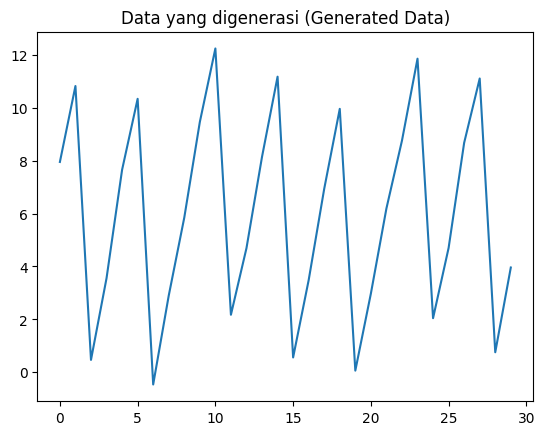

In [4]:
plt.plot(x_original)
plt.title("Data yang digenerasi (Generated Data)")
plt.show()

### Merusak Data (Corrupting Data)

Secara sengaja, data dirusak pada Indeks 1 dan Indeks 2 ($i_1 \text{dan} i_2$) menggunakan

_(Intentionally, data is corrupted at Index 1 and Index 2 ($i_1 \text{and} i_2$) using)_

$$i_1 = d_3 , i_2 = d_3 + d_1$$

---

Namun, apabila $i_1$ atau $i_2$ melebihi $N - 1$ maka indeks tersebut harus di operasikan dengan $mod N$.

(_However, if $i_1$ or $i_2$ exceeds $N - 1$ then the index must be calculated using this operation, $mod N$._)

---

Setelah itu dataset dirusak berdasarkan indeks $i_1$ dan $i_2$ dengan rumus berikut

_After that the dataset is corrupted based on the index $i_1$ and $i_2$ with the following formula_

$$x_{i_1} = x_{i_1} + 2M, x_{i_2} = x_{i_2} - 2M$$


#### Code


In [5]:
# Mengacak Data (Data Corruption)
i1 = d3
i2 = (d3 + d1) % N

x[i1] -= 2 * M
x[i2] += 2 * M

#### Visualization


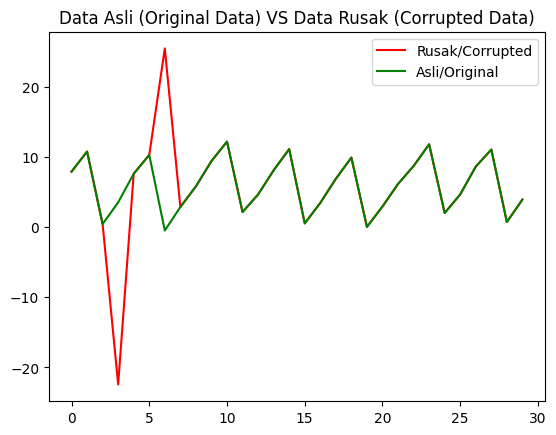

In [6]:
plt.plot(x, label="Rusak/Corrupted", color="red")
plt.plot(x_original, label="Asli/Original", color="green")
plt.title("Data Asli (Original Data) VS Data Rusak (Corrupted Data)")
plt.legend()
plt.show()

## Menghitung (Calculating) Moving Average

Moving Average dihitung dengan rumus sebagai berikut

(_Moving Average is calculated using the following formula_)

$$\bar{x}_i = \frac{1}{k} \sum_{j=i-k+1}^{i} x_j$$

---

Namun $k$ didapatkan dari (_However, $k$ can be obtained from_)

$$k = 3 + (d_1 mod 3)$$


#### Code


In [7]:
# Mendapatkan k (Obtaining k)
k = 3 + (d1 % 3)

def moving_average(x, k):
    # Membuat Variabel Rata-Rata (Making Variabel Average)
    data = np.zeros(N)

    # Kalkulasi (Calculate)
    for i in range(N):
        j = i - k + 1

        if j >= 0:
            temp = 0
            for ii in range(j, i+1):
                temp += x[ii]
            data[i] = temp/k
        else:
            data[i] = x[i]

    # Mengembalikan Data (Returning Data)
    return data

# Rata-rata ke x_bar (Average to x_bar)
x_bar = moving_average(x, k)

#### Visualization


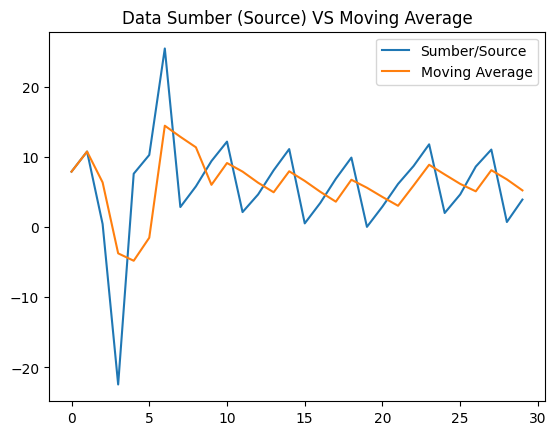

In [8]:
plt.plot(x, label="Sumber/Source")
plt.plot(x_bar, label="Moving Average")
plt.title("Data Sumber (Source) VS Moving Average")
plt.legend()
plt.show()

## Mencari Outlier (Hunting Down Outlier)


### Z-Score

Untuk mencari Z-Score untuk setiap data diperlukan rumus-rumus berikut

(_In order to find the Z-Score for each data, all you need are these formulas_)

$$\mu = \frac{1}{N} \sum^{N}_{i=1} x_i$$

$$\sigma = \sqrt{\frac{1}{N} \sum^{N}_{i=1} (x_i - \mu)^2}$$

$$z_i = \frac{x_i - \mu}{\sigma}$$


### Outlier

Data dapat dikategorikan sebagai outlier apabila melebihi suatu batasan yaitu (_Data can be identified as an outlier if they pass certain treshold which is_)

$$T = 1.5 + 0.1 \cdot d_1$$

Outlier:

$$|z_i| > T$$


#### Code


In [9]:
# Batasan (Threshold)
threshold = 1.5 + 0.1 * d1

def detect_outliers(x, threshold):
    # Rata-rata (Average) \mu
    avg = 0

    for i in range(N):
        avg += x[i]
    avg /= N

    # tdDev \sigma
    stdDev = 0
    for i in range(N):
        stdDev += pow((x[i] - avg), 2)
    stdDev = sqrt(stdDev/N)

    # Z-Score
    zScore = np.zeros(N)
    for i in range(N):
        zScore[i] = (x[i] - avg)/stdDev

    # Mendeteksi (Detecting) Outliers

    data = []
    for i in range(N):
        data.append([])
        if (abs(zScore[i]) > threshold):
            data[i].append("Outlier")
        else:
            data[i].append("Normal")
        data[i].append(x[i])
        data[i].append(zScore[i])

    # Mengembalikan (Return)
    return data, stdDev, avg


# Transparansi AI (AI Transparency)
# Bagian tertentu dari kode ditambahkan untuk mengakomodasi kode yang dihasilkan AI di bawah ini, informasi transparansi lebih lanjut akan tersedia.
# (Certain part of the code is added to account for the AI generated code below, more transparency information will be available)

# X Outlier!
x_outlier, stdDev, avg = detect_outliers(x, threshold)

# Menampilkan dtaa (Print Out the Data)
for i in range(N):
    print(f"{x_outlier[i][0]:<10s}: {x_outlier[i][1]: < 15f} (Z-Score: {x_outlier[i][2]})")

Normal    :  7.948637       (Z-Score: 0.27181161075198157)
Normal    :  10.818243      (Z-Score: 0.6648615779685769)
Normal    :  0.467538       (Z-Score: -0.7528743462246424)
Outlier   : -22.444732      (Z-Score: -3.8911677782339402)
Normal    :  7.651533       (Z-Score: 0.23111726458920975)
Normal    :  10.334406      (Z-Score: 0.5985904282760892)
Outlier   :  25.538320      (Z-Score: 2.6810703776066314)
Normal    :  2.896063       (Z-Score: -0.4202394371340634)
Normal    :  5.845698       (Z-Score: -0.016227918181771498)
Normal    :  9.458501       (Z-Score: 0.47861773670469554)
Normal    :  12.237329      (Z-Score: 0.8592337674128431)
Normal    :  2.173820       (Z-Score: -0.5191649469471815)
Normal    :  4.691566       (Z-Score: -0.17430929227172823)
Normal    :  8.143566       (Z-Score: 0.29851108277489397)
Normal    :  11.171284      (Z-Score: 0.7132175400110902)
Normal    :  0.559755       (Z-Score: -0.7402434107349866)
Normal    :  3.482411       (Z-Score: -0.3399273375696824)

#### Visualization

> **_Transparansi AI (AI Transparency):_**
>
> Kode dibawah digenerasi oleh **Google Gemini 3 Fast Model**. Dengan beberapa modifikasi dari penulis.
>
> (_The code below was generated by **Google Gemini 3 Fast Model**, with some modifications by the author._)


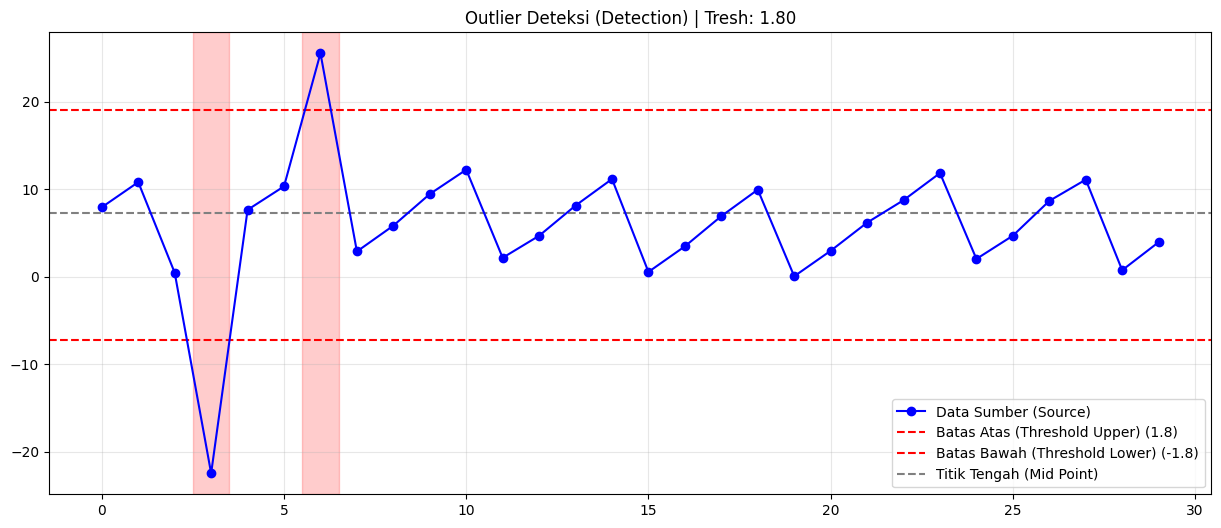

In [10]:
# Ambil data untuk plotting (Get data for plotting)
plt.figure(figsize=(15, 6))

# 1. Background Bar - Merah jika Outlier (Red if Outlier)
for i in range(N):
    if x_outlier[i][0] == "Outlier":
        # Menghasilkan bar merah transparan di belakang titik outlier (Generate transparent red bar behind outlier points)
        plt.axvspan(i-0.5, i+0.5, color='red', alpha=0.2)

# 2. Garis Data X - Data Asli (Original Data)
plt.plot(x, marker='o', color='blue', label='Data Sumber (Source)', zorder=3)

# 3. Garis Horizontal Threshold - Dikonversi ke skala X (Converted to X scale)
# Rumus balik (Inverse formula): X = (Z * sigma) + mu
upper_limit = (threshold * stdDev) + avg
lower_limit = (-threshold * stdDev) + avg

plt.axhline(y=upper_limit, color='red', linestyle='--', label=f'Batas Atas (Threshold Upper) ({threshold})')
plt.axhline(y=lower_limit, color='red', linestyle='--', label=f'Batas Bawah (Threshold Lower) (-{threshold})')
plt.axhline(y=stdDev, color='grey', linestyle='--', label=f'Titik Tengah (Mid Point)')

# Dekorasi (Decoration)
plt.title(f"Outlier Deteksi (Detection) | Tresh: {threshold:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Fungsi Potongan (_Piecewise Function_)

Data ditransformasikan menggunakan fungsi potongan

(_The data can be transform with piecewise function_)

$$
y(x) = \left\{\begin{matrix}
    x^2, & x<t_1 \\
    \sqrt{x}, & t_1 \leq x < t_2 \\
    log(x), & x \geq t_2
\end{matrix} \right.
$$

dengan (_with_):

$$t_1 = d_1, t_2 = d_1 + d_2 + 5$$

Penanganan kasus khusus wajib dijelaskan dan diterapkan (_Handling of special cases must be explained and implemented_):

- Jika (If) $x < 0$ on $\sqrt{x}$, gunakan (use) $\sqrt{|x|}$
- Jika (If) $x \leq 0$ on $log (x)$, gunakan (use) $log (1+|x|)$


#### Code

In [11]:
# t1 & t2
t1 = d1
t2 = d1 + d2 + 5

# Fungsi Potongan (Piecewise Function)
def piecewise_transform(x, t1, t2):
  data = np.zeros(N)

  for i in range(N):
    DRYer = x[i]
    if (DRYer < t1):
      data[i] = pow(DRYer, 2)
    elif (DRYer < t2):
      data[i] = sqrt(abs(DRYer))
    else:
      # Ternary Python (trueVal if condition else falseVal)
      # (Sc: https://www.geeksforgeeks.org/python/ternary-operator-in-python/)
      data[i] = log(1 + abs(DRYer)) if DRYer <= 0 else log(DRYer)

  return data

pwTf = piecewise_transform(x, t1, t2)
pwTf

array([2.81933269e+00, 3.28910980e+00, 2.18592229e-01, 5.03765995e+02,
       2.76614040e+00, 3.21471714e+00, 3.24018009e+00, 8.38717805e+00,
       2.41778780e+00, 3.07546766e+00, 3.49818943e+00, 4.72549461e+00,
       2.16600240e+00, 2.85369343e+00, 3.34234706e+00, 3.13325984e-01,
       1.86612182e+00, 2.63334576e+00, 3.15524646e+00, 3.88326328e-03,
       8.83113665e+00, 2.48786875e+00, 2.95867629e+00, 3.44260190e+00,
       4.17689076e+00, 2.16763113e+00, 2.94489752e+00, 3.33199677e+00,
       5.71725061e-01, 1.98980454e+00])

#### Visualization

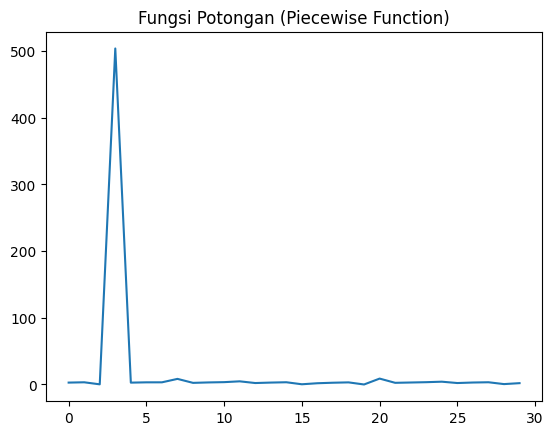

In [12]:
plt.plot(pwTf)
plt.title("Fungsi Potongan (Piecewise Function)")
plt.show()

## Ringkatan (Summary) Data

Data harus diringkas menjadi satu *return*: `min, max, mean, median, std, Q1, Q3, and IQR`. IQR (*Interquartile Range*) sendiri diambil dari...

*(The data must be summarized into a single return: min, max, mean, median, std, Q1, Q3, and IQR. The IQR (Interquartile Range) itself is taken from...)*

$$IQR = Q_3 - Q_1$$

In [13]:
# Ringkasan Statiska (Summary Stats)
def summary_stat(x):
  min = np.min(x)
  max = np.max(x)
  mean = np.average(x)
  median = np.median(x)
  std = np.std(x)

  # Sc: https://numpy.org/doc/2.1/reference/generated/numpy.quantile.html
  Q1, Q3 = np.quantile(x, [1/4, 3/4])

  # IQR
  IQR = Q3 - Q1

  return [min, max, mean, median, std, Q1, Q3, IQR]

# Teknisnya, cara ini sedikit lebih boros di penggunaan RAM, tapi dampaknya tidak terlalu signifikan dalam kasus kita.
# (Technically, this method is a bit more memory intensive, but the impact is insignificant in our case.)
min, max, mean, median, std, Q1, Q3, IQR = summary_stat(x)
stats = summary_stat(x)

# Printout Data
print(f"{"Minimum":<10s}: {stats[0]}")
print(f"{"Maximum":<10s}: {stats[1]}")
print(f"{"Mean":<10s}: {stats[2]}")
print(f"{"Median":<10s}: {stats[3]}")
print(f"{"Std Dev":<10s}: {stats[4]}")
print(f"{"Q1":<10s}: {stats[5]}")
print(f"{"Q3":<10s}: {stats[6]}")
print(f"{"IQR":<10s}: {stats[7]}")

Minimum   : -22.4447320029165
Maximum   : 25.538320429399135
Mean      : 5.964175754026548
Median    : 6.562000404607016
Std Dev   : 7.300869398604247
Q1        : 2.914977591238711
Q3        : 9.83131049027798
IQR       : 6.916332899039269


## Keputusan Akhir (Final Decision)

Keputusan ditentukan dengan 3 keluaran **AMAN (SAFE)**, **WASPADA (ALERT)**, **BAHAYA (DANGER)**. Keputusan diambil berdasarkan rumus sebagai berikut:

*The decision is determined by 3 outputs **AMAN (SAFE)**, **WASPADA (ALERT)**, **BAHAYA (DANGER)**. The decision is taken based on the following formula:*

$$\text{Keputusan/Decision} = \left\{
\begin{matrix}
\text{BAHAYA (DANGER)}, & n_\text{outlier} \geq b \\
\text{BAHAYA (DANGER)}, & (n_\text{outlier} \geq a) \wedge (\sigma > \beta) \wedge (IQR > α) \\
\text{WASPADA (ALERT)}, & (n_\text{outlier} \geq a) \vee (IQR > \alpha) \vee (|\mu - \text{median}| > γ) \\
\text{AMAN (SAFE)}, & \text{Syarat Tidak Terpenuhi/Condition Not Met} \\
\end{matrix}
\right.$$

---

Rumus Pendukung (*Supporting Formulas*):

Jumlah Outlier (*Number of Outliers*)

$$n_\text{outlier} = \sum 1 (|z_i| > T)$$

Ambang Jumlah Outlier (*Outlier Threshold*)

$$a = 1 + (d_2 mod 2), b = a + 2$$

Ambang Sebaran Data (*Data Distribution Threshold*)

$$\alpha = (1 + 0.1 \cdot d_1) \times IQR$$

$$\beta = (1 + 0.1 \cdot d_2) \times \sigma$$

Ambang Ketidaksimetrian Distribusi (*Distribution Dissymmetry Threshold*)

$$\gamma = (0.1 + 0.02 \cdot d_3) \times |\mu|$$

In [14]:
# Data Variabel Pendukung (Supporting Formulas Data)
# n_outlier
n_outlier = 0
for i in range(N):
  if x_outlier[i] == "Outlier":
    n_outlier += 1
  # Karena dari awal data outlier sudah diurutkan berdasarkan kategori, kita dapat mencocokkan string yang ada, daripada menghitung semuanya kembali dari awal.
  # (Since the outlier data is already sorted by category from the start, we can match the existing strings, rather than recalculating everything from scratch.)

# alpba
alpha = (1 + 0.1 * d1) * IQR

# beta
beta = (1 + 0.1 * d2) * std

# gamma
gamma = (0.1 + 0.02 * d3) * abs(avg)

# a
a = 1 + (d2 % 2)

# b
b = a + 2

# Deteksi Outlier (Detection)
def decision_report(stats, n_outlier, alpha, beta, gamma, a, b):
  if (n_outlier >= b) or ((n_outlier >= a) and (stdDev > beta) and (IQR > alpha)):
    decision = "BAHAYA (DANGER)"
  elif ((n_outlier >= a) or (stdDev > beta) or (IQR > alpha) or (abs(avg - median) > gamma)):
    decision = "WASPADA (ALERT)"
  else: decision = "AMAN (SAFE)"

  return decision, stats

decision, stats = decision_report(stats, n_outlier, alpha, beta, gamma, a, b)

# Printout Data
print(f"NIM/Student ID: {studentID}\n")
print(f"{"Minimum":<10s}: {stats[0]}")
print(f"{"Maximum":<10s}: {stats[1]}")
print(f"{"Mean":<10s}: {stats[2]}")
print(f"{"Median":<10s}: {stats[3]}")
print(f"{"Std Dev":<10s}: {stats[4]}")
print(f"{"Q1":<10s}: {stats[5]}")
print(f"{"Q3":<10s}: {stats[6]}")
print(f"{"IQR":<10s}: {stats[7]}\n")
print(f"Keputusan Akhir (Final Decision): {decision}\n")

NIM/Student ID: 2902583383

Minimum   : -22.4447320029165
Maximum   : 25.538320429399135
Mean      : 5.964175754026548
Median    : 6.562000404607016
Std Dev   : 7.300869398604247
Q1        : 2.914977591238711
Q3        : 9.83131049027798
IQR       : 6.916332899039269

Keputusan Akhir (Final Decision): AMAN (SAFE)



# **Kata Akhir (Final Word)**

Disini kita belajar bahwa 3 digit akhir NIM, dapat di gunakan sebagai sumber data utama untuk mengambil suatu keputusan: **Aman**, **Waspada**, **Bahaya**.

Dapat disimpulkan bahwa banyak sekali ilmu pengetahuan yang berhubungan dengan **Statiska Dasar** digunakan di kelas **Komputasi Ilmiah**.

Berikut dokumen Jupyter Notebook dapat saya konklusikan, Terima Kasih.

Salam Hormat,
**Ruben Hu (2902583383)**

---

*Here we learn that the last three digits of a student ID number can be used as the primary data source for making decisions: **Safe**, **Alert**, **Danger**.*

*It can be concluded that a great deal of knowledge related to **Basic Statistics** is used in the **Scientific Computing** class.*

*Here's the Jupyter Notebook document I can summarize. Thank you.*

*Best regards,
**Ruben Hu (2902583383)***

# **Transparansi AI (AI Transparency)**

Dalam pekerjaan ini, model kecerdasan buatan digunakan untuk memahami, mengevaluasi, dan meningkatkan dokumentasi. Jika ada kode yang dibuat seluruhnya (atau sebagian) dengan model kecerdasan buatan, **penulis harus mengungkapkan informasi tersebut.**

***Model Kecerdasan Buatan yang digunakan: Google Gemini 3 (Bahasa Model Besar)***

---

In this coursework, artificial intelligence models are used to understand, evaluate, and improve documentation. If any code is written entirely (or partially) with artificial intelligence models, **the authors must disclose this information.**

***Artificial Intelligence Model Used: Google Gemini 3 (Large Model Language)***